# Student Academic Performance Analysis

This notebook explores student performance factors and builds machine learning models to predict Exam_Score.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('../data/StudentPerformanceFactors.csv')
df


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


## Dataset Overview

The following cells check the dataset size, columns, data types, and missing values.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [3]:
df.shape

(6607, 20)

In [4]:
df.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

## Exploratory Data Analysis

In [5]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
missing_cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']

for col in missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

A small number of missing values were found in Teacher_Quality, Parental_Education_Level, and Distance_from_Home. Since these are categorical columns, I filled the missing values using the most common value in each column instead of removing the rows. This keeps more data for the analysis while still making the dataset complete.

In [8]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

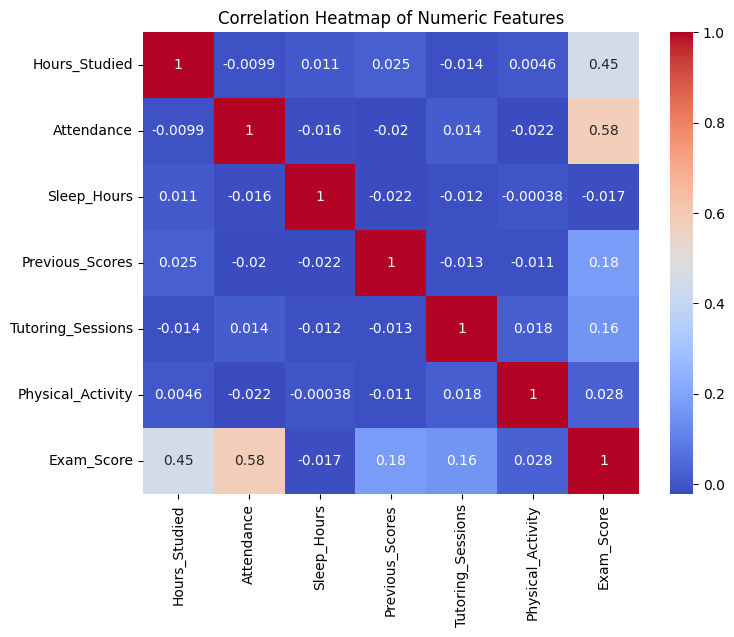

In [9]:
numeric_corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

The correlation heatmap shows the relationships between numerical variables in the dataset. Among all features, attendance has the strongest positive correlation with exam score (0.58), followed by hours studied (0.45). This suggests that students who attend more classes and spend more time studying tend to perform better on exams. Other variables such as previous scores and tutoring sessions show weaker positive relationships, while sleep hours and physical activity appear to have little to no correlation with exam performance.

In [10]:
numeric_corr['Exam_Score'].sort_values(ascending=False)

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64

Based on the correlation values, Attendance and Hours_Studied have the strongest positive relationships with Exam_Score. Previous_Scores and Tutoring_Sessions also have positive relationships, but they are weaker. Sleep_Hours and Physical_Activity show little to no direct relationship with exam performance.

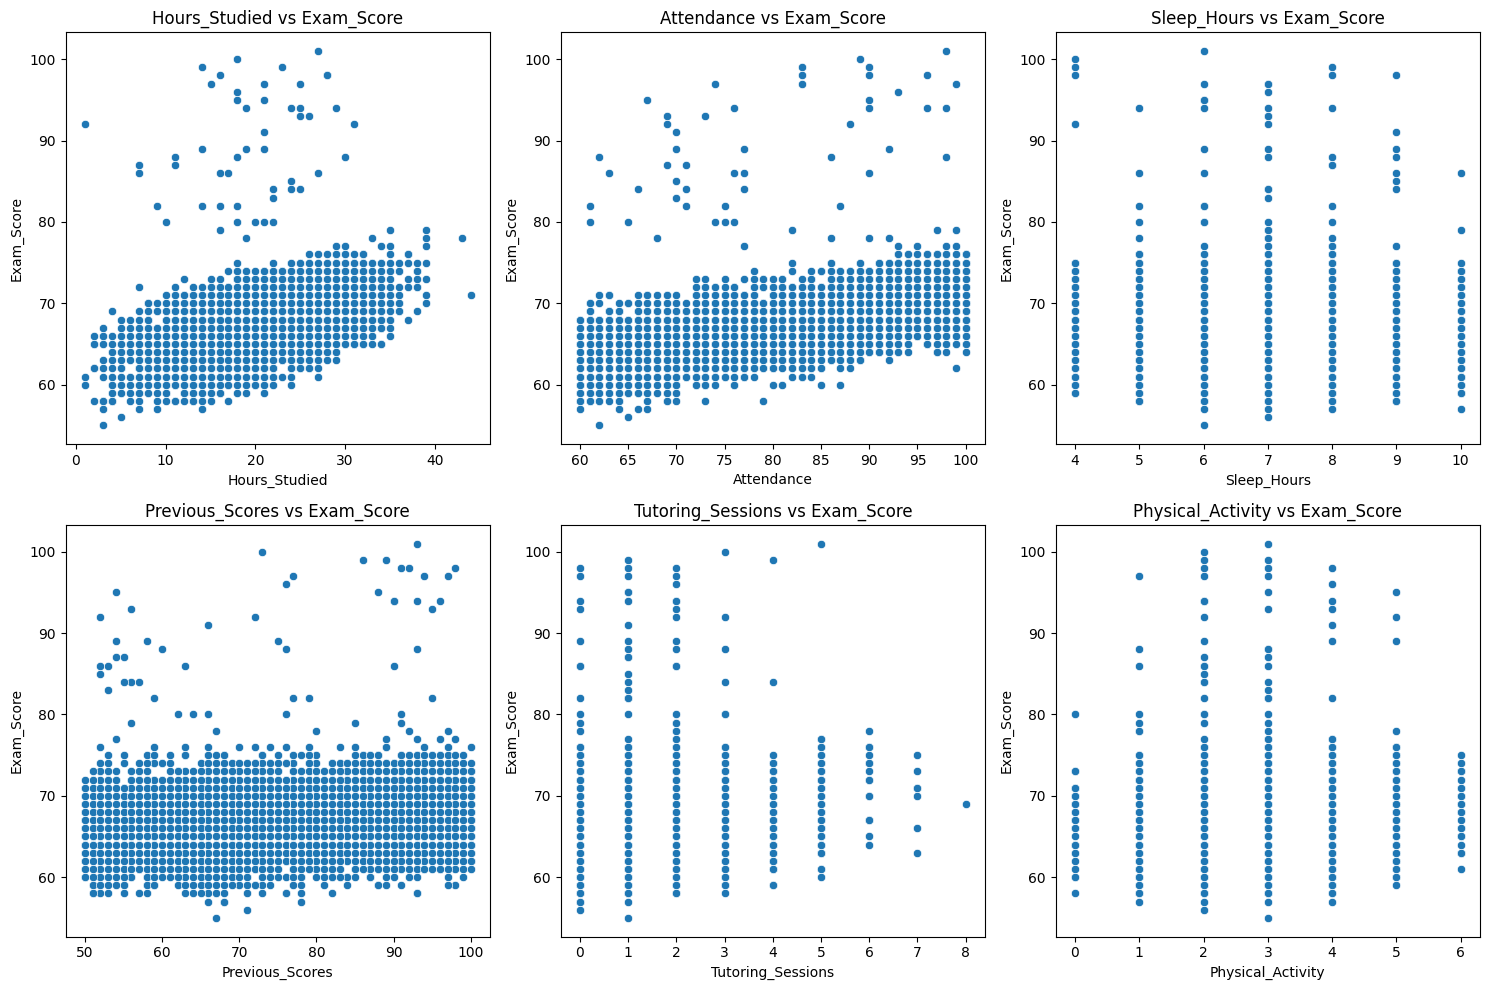

In [11]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('Exam_Score')

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(data=df, x=col, y='Exam_Score', ax=axes[i])
    axes[i].set_title(f'{col} vs Exam_Score')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The scatterplots show how each numeric variable relates to exam score. Attendance and hours studied display the strongest positive relationships, as higher values in these variables generally correspond to higher exam scores. Previous scores and tutoring sessions show weaker positive trends, meaning they have some influence but are not as strong as Attendance or Hours_Studied. In contrast, sleep hours and physical activity do not show a clear pattern, indicating little to no direct relationship with exam performance. Overall, the results suggest that consistent attendance and study time are the most important numeric factors associated with higher exam scores.

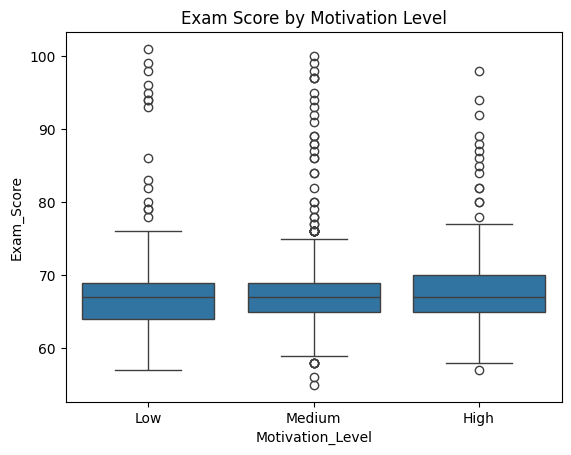

In [12]:
sns.boxplot(data=df, x='Motivation_Level', y='Exam_Score')
plt.title('Exam Score by Motivation Level')
plt.show()

Students with higher motivation levels tend to have slightly higher median exam scores. The distribution for “High” motivation is slightly shifted upward compared to “Low,” suggesting that motivation has a positive but moderate impact on performance.

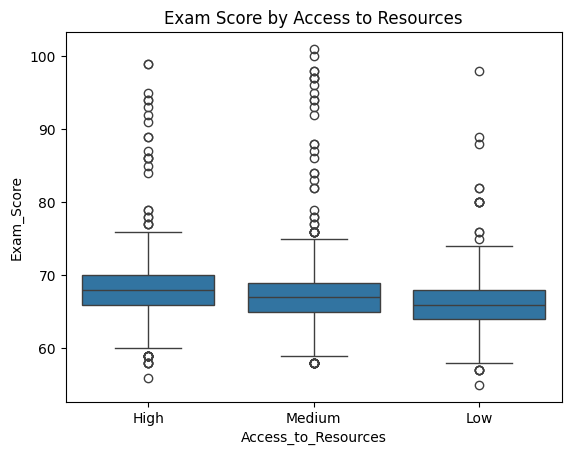

In [13]:
sns.boxplot(data=df, x='Access_to_Resources', y='Exam_Score')
plt.title('Exam Score by Access to Resources')
plt.show()

Students with higher access to resources generally show slightly higher exam scores. However, the differences between groups are not very large, indicating that while resources help, they may not be the most dominant factor.

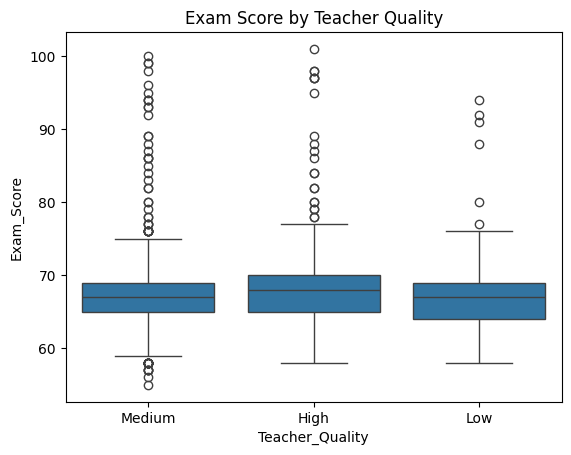

In [14]:
sns.boxplot(data=df, x='Teacher_Quality', y='Exam_Score')
plt.title('Exam Score by Teacher Quality')
plt.show()

Students with higher teacher quality tend to perform slightly better on average. The median exam score for “High” teacher quality is higher than “Low,” suggesting that teaching quality has a positive influence, though the effect is moderate.

The scatterplots and boxplots show the presence of some outliers, particularly at higher exam scores. These points represent students who performed significantly better than the majority. Since these values are realistic and not data errors, they were retained in the analysis. However, they may slightly influence the overall trends observed.

Overall, Attendance and Hours_Studied appear to be the most important factors associated with higher exam scores, while other variables show weaker or minimal impact.

## Linear Regression Model

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Exam_Score', axis=1)
y = df_encoded['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 3.2560199870428934
RMSE: 1.8044445092722838
R²: 0.7696495724907313


The linear regression model performed well, with an R² score of about 0.77. This means the model explains around 77% of the variation in exam scores. The RMSE is around 1.8, meaning the model’s predictions are typically off by about 2 exam-score points.

In [17]:
coefficients = pd.Series(model.coef_, index=X.columns)
coefficients.sort_values(ascending=False).head(10)



Peer_Influence_Positive                  1.051673
Internet_Access_Yes                      0.958665
Distance_from_Home_Near                  0.854336
Extracurricular_Activities_Yes           0.583275
Peer_Influence_Neutral                   0.566898
Parental_Education_Level_Postgraduate    0.514748
Tutoring_Sessions                        0.507744
Distance_from_Home_Moderate              0.317733
Hours_Studied                            0.293169
Attendance                               0.198853
dtype: float64

In [18]:
coefficients_abs = coefficients.abs().sort_values(ascending=False).head(10)
coefficients_abs

Access_to_Resources_Low        2.101150
Parental_Involvement_Low       2.001684
Family_Income_Low              1.108291
Parental_Involvement_Medium    1.069448
Peer_Influence_Positive        1.051673
Motivation_Level_Low           1.043881
Access_to_Resources_Medium     1.031581
Teacher_Quality_Low            1.015959
Internet_Access_Yes            0.958665
Learning_Disabilities_Yes      0.857212
dtype: float64

The coefficient results show which features had the strongest influence in the linear regression model. Positive coefficients increase the predicted exam score, while negative coefficients lower the predicted exam score. The absolute coefficient table shows the features with the largest overall effect, regardless of direction.

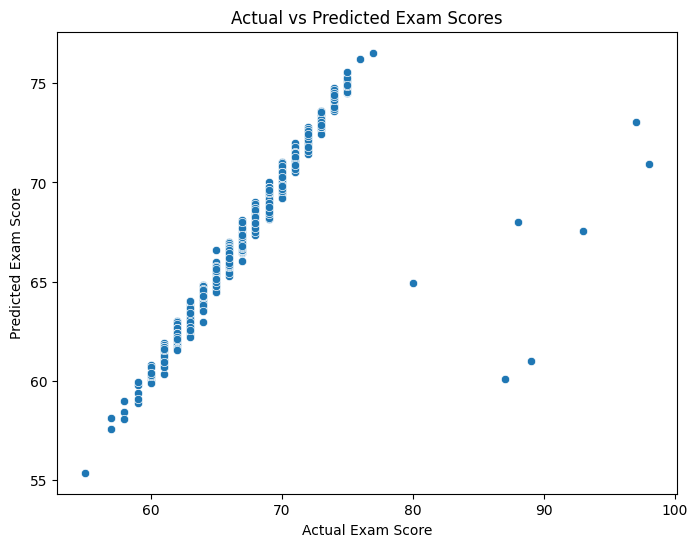

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')
plt.show()

The actual vs predicted plot shows a clear positive relationship, meaning the model is capturing the overall trend in the data. Most predictions are close to the actual values, especially in the mid-range of exam scores.

However, the model tends to underestimate higher exam scores. While actual scores can reach above 90, the predicted values are generally lower. This suggests that the model performs well overall but may struggle to fully capture extreme high-performing cases. This indicates slight underfitting, where the model is too simple to capture more complex patterns in the data.

## Model Comparison

To evaluate model performance, three regression models were tested using the same train-test split.

### Random Forest Model



In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MSE: 4.987182904689864
RMSE: 2.2332001488200435
R²: 0.6471767007776992


A Random Forest model was tested to compare against linear regression. Random Forest can capture more complex patterns, but in this case it performed worse than linear regression, with a lower R² score and higher error.

### Gradient Boosting Model

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

Gradient Boosting Results
MSE: 3.8114423258006114
RMSE: 1.9522915575806323
R²: 0.7303556573150954


A Gradient Boosting model was also tested because it can sometimes perform better on tabular data. It performed better than Random Forest, but still did not outperform the linear regression model.

### Model Comparison Summary

Linear Regression performed the best overall with the highest R² score and lowest RMSE. Gradient Boosting was the second-best model, while Random Forest performed the weakest.

This suggests that the relationship between the features and Exam_Score is largely linear. More complex models did not improve performance, so Linear Regression is the most appropriate choice for this dataset.

Additionally, the results indicate that increasing model complexity does not always lead to better performance, especially when the underlying relationships in the data are relatively simple.

### Model Performance Comparison Table


In [25]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MSE': [mse, mse_rf, mse_gb],
    'RMSE': [rmse, rmse_rf, rmse_gb],
    'R2 Score': [r2, r2_rf, r2_gb]
})

model_comparison.sort_values(by='R2 Score', ascending=False).style.format({
    'MSE': '{:.3f}',
    'RMSE': '{:.3f}',
    'R2 Score': '{:.3f}'
})

,Model,MSE,RMSE,R2 Score
0,Linear Regression,3.256,1.804,0.770
2,Gradient Boosting,3.811,1.952,0.730
1,Random Forest,4.987,2.233,0.647


The table summarizes the performance of all models using MSE, RMSE, and R² score. Linear Regression achieves the highest R² and lowest RMSE, indicating the best overall performance. Gradient Boosting performs moderately well, while Random Forest shows the weakest performance among the models.